In [2]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.ensemble import IsolationForest

# +
# ONLY your selected posts
poster = [
    # EGENKAPITAL
    "20000","20100","20200","20300",
    "20410","20420","20450","20550","20590","20800",

    # FOREIGN OWNERSHIP
    "20001","20002","20003","20004",

    # LONG-TERM DEBT
    "21300","21600","22000","22100",
    "22200","22500","22600","22800","22900"]

valutaer = ["NOK","EUR","USD"]
land = ["NO","SE","DK","US"]
perioder = ["202103","202106","202309","202312"]

rows = []

for _ in range(20000):
    post = random.choice(poster)

    under_post = "00"

    org_nummer = str(random.randint(100000000,999999999))

    # ✅ IMPORTANT: keep as NUMBER (not string)
    verdi = round(random.uniform(0,100_000_000),2)

    periode = random.choice(perioder)
    landkode = random.choice(land)
    valuta = random.choice(valutaer)

    rows.append({
        "post": post,
        "under_post": under_post,
        "org_nummer": org_nummer,
        "verdi": verdi,
        "periode": periode,
        "land": landkode,
        "valuta": valuta
    })

df = pd.DataFrame(rows)

print(df.head())
# -

verdi = round(random.uniform(0,100_000_000),2)
#Keep values numeric#

#Create dataframe#
df = pd.DataFrame(rows)

#Convert dtype#
df["verdi"] = df["verdi"].astype(float)

# # Prepare ML features

# +
df["post_code"] = df["post"].astype(int)
df["periode_code"] = df["periode"].astype(int)



    post under_post org_nummer        verdi periode land valuta
0  22600         00  368574643   9085409.72  202309   SE    NOK
1  20100         00  536438332  35665652.46  202312   NO    USD
2  22000         00  875853096  26973642.34  202309   US    EUR
3  20800         00  459392911   6659538.98  202106   SE    EUR
4  22100         00  855297541  87372122.69  202312   US    USD


In [3]:
idx = df.sample(2000, random_state=1).index

df["verdi_ny"] = df["verdi"]

df.loc[idx, "verdi_ny"] = (
    df.loc[idx, "verdi"]
    + np.random.randint(-50000, 50001, size=2000)
)

In [4]:
#Lage løpenummer
df["loepenummer"] = np.random.choice(
    [1, 2, 3, 4],
    size=len(df),
    p=[0.2, 0.3, 0.45, 0.05]
)

df.head()

In [5]:
df["endring"] = df["verdi_ny"] - df["verdi"]
df.head()

,post,under_post,org_nummer,verdi,periode,land,valuta,post_code,periode_code,verdi_ny,loepenummer,endring
0,22600,00,368574643,9085409.72,202309,SE,NOK,22600,202309,9085409.72,1,0.0
1,20100,00,536438332,35665652.46,202312,NO,USD,20100,202312,35665652.46,3,0.0
2,22000,00,875853096,26973642.34,202309,US,EUR,22000,202309,26973642.34,3,0.0
3,20800,00,459392911,6659538.98,202106,SE,EUR,20800,202106,6659538.98,1,0.0
4,22100,00,855297541,87372122.69,202312,US,USD,22100,202312,87379542.69,4,7420.0


In [6]:
#Lag kolonner "verdi_4850322", "verdi_4851222", "verdi_4850922", "verdi_4850622"

df["verdi_4850322"] = np.random.randint(0, 500001, size=len(df))
df["verdi_4851222"] = np.random.randint(0, 500001, size=len(df))
df["verdi_4850922"] = np.random.randint(0, 500001, size=len(df))
df["verdi_4850622"] = np.random.randint(0, 500001, size=len(df))

In [7]:
df["endring"].value_counts()

endring
 0.0        18001
 11766.0        2
 49854.0        2
 1502.0         2
 39569.0        2
            ...  
-28991.0        1
 44020.0        1
-20753.0        1
-37477.0        1
 45914.0        1
Name: count, Length: 1980, dtype: int64

In [8]:
X = df[["verdi","post", "under_post", "org_nummer", "loepenummer", "periode_code", "verdi_4850322", "verdi_4851222", "verdi_4850922", "verdi_4850622"]] #Land valuta prefix post under_post, verdi, kommentar, org_foretak, org_foretak_navn
y = df[["endring"]] #kv4850323 ser på 1.kvartal 2023

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import warnings
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score
gb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)
 
gb_model.fit(X_train, y_train)
 
y_pred = gb_model.predict(X_test)
 
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 2925.1769756302833
R2: -0.0009415820388727347


/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


        post under_post org_nummer        verdi periode land valuta  \
9620   22000         00  174367764  11449535.55  202103   US    EUR   
17159  20300         00  674241539  66276691.75  202103   US    USD   
17161  20002         00  496492567  80914699.15  202103   NO    USD   
4363   20000         00  913779186  95070253.76  202103   SE    NOK   
14024  21300         00  465590655  67422019.58  202103   US    EUR   

       post_code  periode_code  anomaly     verdi_ny  endring  
9620       22000        202103        1  11449535.55      0.0  
17159      20300        202103        1  66276691.75      0.0  
17161      20002        202103        1  80914699.15      0.0  
4363       20000        202103        1  95070253.76      0.0  
14024      21300        202103        1  67390402.58 -31617.0  


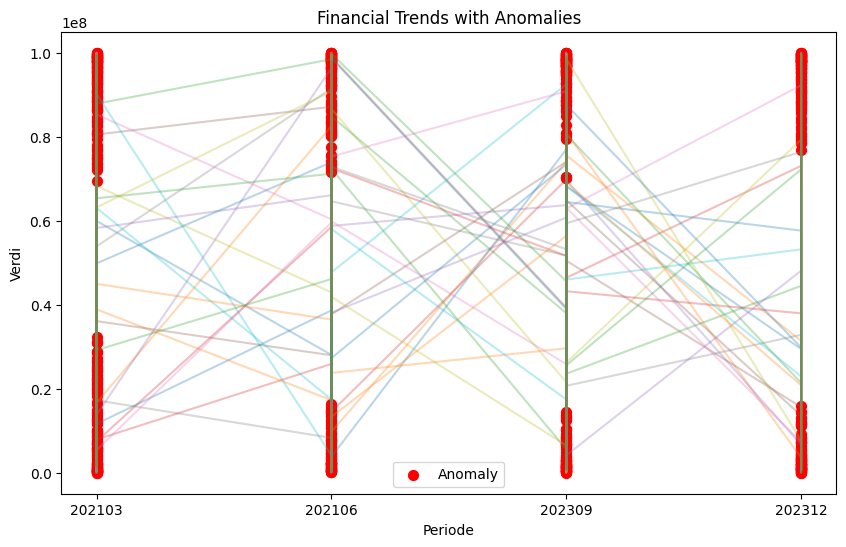

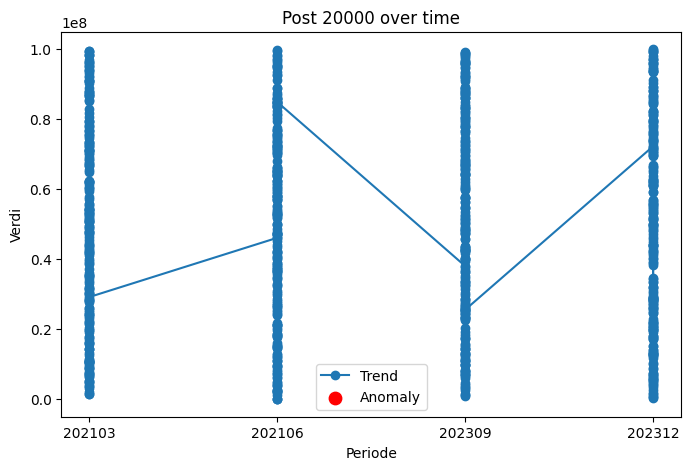

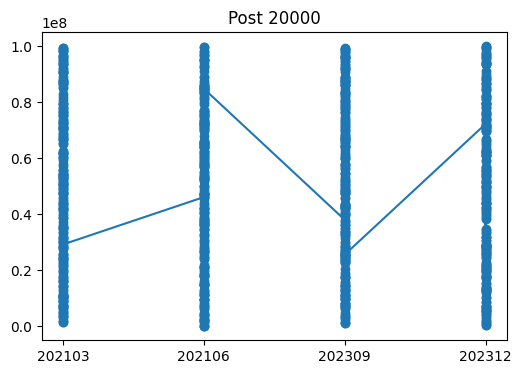

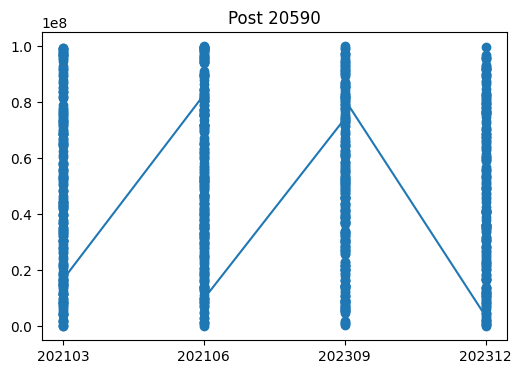

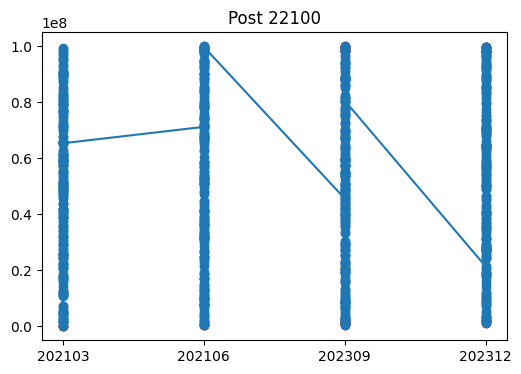

In [ ]:
X = df[["verdi","post_code","periode_code"]]
y = df[["endring"]]

# # Apply ML model

# +
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05)

df["anomaly"] = model.fit_predict(X)
# -

print(df.head())

# # Sort data by period

df = df.sort_values(by="periode")

# # Line plot

# +
plt.figure(figsize=(10,6))

# Plot all data (faint lines)
for post in df["post"].unique():
    subset = df[df["post"] == post]
    plt.plot(subset["periode"], subset["verdi"], alpha=0.3)

# Highlight anomalies
anomaly = df[df["anomaly"] == -1]
plt.scatter(anomaly["periode"], anomaly["verdi"], color="red", s=50, label="Anomaly")

plt.title("Financial Trends with Anomalies")
plt.xlabel("Periode")
plt.ylabel("Verdi")
plt.legend()

plt.show()

# +
post_example = "20000"

subset = df[df["post"] == post_example]

plt.figure(figsize=(8,5))

plt.plot(subset["periode"], subset["verdi"], marker="o", label="Trend")
plt.scatter(subset[subset["anomaly"]==-1]["periode"],
            subset[subset["anomaly"]==-1]["verdi"],
            color="red", label="Anomaly", s=80)

plt.title(f"Post {post_example} over time")
plt.xlabel("Periode")
plt.ylabel("Verdi")
plt.legend()

plt.show()
# -

for post in ["20000","20590","22100"]:
    subset = df[df["post"] == post]

    plt.figure(figsize=(6,4))

    plt.plot(subset["periode"], subset["verdi"], marker="o")

    plt.scatter(subset[subset["anomaly"]==-1]["periode"],
                subset[subset["anomaly"]==-1]["verdi"],
                color="red")

    plt.title(f"Post {post}")
    plt.show()

subset = df[df["post"] == post_example]